**This version inherits from FullPipeline_v1.5.ipynb**

*This version modified *

This version is the THIRD experiment described in MS2 report: early integration with pairwise encoder.

In [1]:
from model_v2_w6ms3.DataLoader import TempFlowDataset_disp
from model_v2_w6ms3.neuralop_seg.uno import UNO

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

Data prep

In [2]:

dataset = TempFlowDataset_disp(
    root = '../../Data',
    split = 'training',
    image_folder = 'image_2',
    flow_type = 'flow_occ',
    disp_type= 'disp_occ',
    seq_len = 4, # 3 flows
    center_frame_idx = 10,
    crop_size = (352, 1216),
    normalize = True,
    stats_in = 'stats.json',
    return_pair_only = False,
)

train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [3]:
batch = next(iter(train_loader))
print(batch['imgs'].shape)

torch.Size([2, 4, 3, 352, 1216])


Encoders

In [4]:
import importlib
import model_v2_w6ms3.Encoders as Encoders
importlib.reload(Encoders)
from model_v2_w6ms3.Encoders import *

import model_v2_w6ms3.Decoders as Decoders
importlib.reload(Decoders)
from model_v2_w6ms3.Decoders import *

import model_v2_w6ms3.Trainers as Trainers
importlib.reload(Trainers)
from model_v2_w6ms3.Trainers import *

In [5]:
# -------------------------
# 1. Pairwise motion encoder
# -------------------------
pair_encoder = SequencePairEncoder(
    feat_ch=64,         # backbone feature channels
    corr_radius=4,      # local cost-volume radius
    embed_ch=128,       # output pair embedding channels
    predict_flow=True   # keep coarse flow_init as optional conditioning / aux target
)

# -------------------------
# 2. Raw visual branch
# -------------------------
visual_branch = VisualBranchCNN(
    in_ch=3,
    base_ch=32,
    out_ch=64
)

# -------------------------
# 3. Pairwise UNO
# -------------------------
# v1 pairwise refinement:
# input = pair_feats only + valid mask
# pair_feats: [B, Tm, 128, h, w], with Tm=3  --> 3*128 = 384 channels
# valid mask adds +1 channel --> total 385
uno = UNO(
    in_channels=385,
    out_channels=128,
    hidden_channels=64,
    lifting_channels=64,
    projection_channels=128,
    positional_embedding='grid',
    n_layers=4,
    uno_out_channels=[64, 96, 96, 64],
    uno_n_modes=[[12, 16], [10, 12], [10, 12], [12, 16]],
    uno_scalings=[[1.0, 1.0], [0.5, 0.5], [2.0, 2.0], [1.0, 1.0]],
    fno_skip="linear",
    horizontal_skip="linear",
    channel_mlp_skip="linear",
)

# -------------------------
# 4. Pairwise motion refiner
# -------------------------
# residual refinement on pair_feats before motion_branch
pair_refiner = PairwiseMotionRefiner(
    uno_module=uno,
    out_ch=128,      # UNO output channels
    pair_ch=128,     # pair_feats channels
    num_pairs=3,     # Tm
    use_flow=False,  # v1: pair_feats only
    use_grads=False, # v1: no flow gradients yet
    use_valid=True   # append low-res valid mask
)

# -------------------------
# 5. Motion branch
# -------------------------
# input still matches pair_feats / refined_pair_feats channels
motion_branch = MotionBranchCNN(
    in_ch=128,
    hidden_ch=128,
    out_ch=64
)

# -------------------------
# 6. Motion-Vision-Light Temporal fusion
# -------------------------
# unchanged for the first pairwise-UNO experiment
fusion = SpatialTemporalFusion_timeAware(
    visual_ch=64,
    motion_ch=64,
    hidden_ch=128,
    out_ch=128
)

# -------------------------
# 7. Decoder
# -------------------------
decoder = FlowDecoder(
    in_ch=128,         # must match fusion output channels
    hidden_ch=128,
    upsample=8,
    use_prev_flow=True
)

Train

In [6]:
def forward_pipeline(imgs, pair_encoder, visual_branch, pair_refiner, motion_branch, fusion,
                     decoder, valid=None):
    """
    imgs: [B, T, 3, H, W]

    Returns dict with:
      flows:               [B, Tm, 2, H, W]
      flow_inits:          [B, Tm, 2, h, w] or None
      pair_feats:          [B, Tm, Cp, h, w]
      refined_pair_feats:  [B, Tm, Cp, h, w]
      corrs:               [B, Tm, K, h, w]
      fused_seq:           [B, Tm, Cf, h, w]
      pair_uno_input:      [B, Cstack, h, w]
      pair_uno_feat:       [B, Cout, h, w]
      delta_pair_feats:    [B, Tm, Cp, h, w]
      valid_lowres:        [B, 1, h, w] or None
    """
    pair_out = pair_encoder(imgs)
    pair_feats = pair_out["pair_feats"]
    flow_inits = pair_out["flow_inits"]
    corrs = pair_out["corrs"]

    B, Tm, _, h, w = pair_feats.shape

    visual_feats = visual_branch(imgs)

    valid_lowres = None
    if valid is not None:
        valid_lowres = downsample_valid_mask(valid, size_hw=(h, w))

    pair_refine_out = pair_refiner(
        pair_feats,
        flow_inits=flow_inits,
        valid_mask=valid_lowres
    )
    refined_pair_feats = pair_refine_out["refined_pair_feats"]
    pair_uno_input = pair_refine_out["pair_uno_input"]
    pair_uno_feat = pair_refine_out["pair_uno_feat"]
    delta_pair_feats = pair_refine_out["delta_pair_feats"]

    motion_feats = motion_branch(refined_pair_feats)
    fused_seq = fusion(visual_feats, motion_feats)

    flows, flow_res = decoder(fused_seq, flow_inits=None)

    return {
        "flows": flows,
        "flow_res": flow_res,
        "flow_inits": flow_inits,
        "pair_feats": pair_feats,
        "refined_pair_feats": refined_pair_feats,
        "corrs": corrs,
        "fused_seq": fused_seq,
        "pair_uno_input": pair_uno_input,
        "pair_uno_feat": pair_uno_feat,
        "delta_pair_feats": delta_pair_feats,
        "valid_lowres": valid_lowres,
    }


class Trainer:
    def __init__(
        self,
        pair_encoder,
        visual_branch,
        pair_refiner,
        motion_branch,
        fusion,
        decoder,
        optimizer,
        device,
        lambda_epe=1.0,
        lambda_temp=0.02,
        lambda_smooth=0.01,
        lambda_self=0.02,
        lambda_flow_res=0.01,
        lambda_mag=0.02,
        lambda_pair_delta=0.001
    ):
        self.pair_encoder = pair_encoder
        self.visual_branch = visual_branch
        self.pair_refiner = pair_refiner
        self.motion_branch = motion_branch
        self.fusion = fusion
        self.decoder = decoder
        self.optimizer = optimizer
        self.device = device

        self.lambda_epe = lambda_epe
        self.lambda_temp = lambda_temp
        self.lambda_smooth = lambda_smooth
        self.lambda_self = lambda_self
        self.lambda_mag = lambda_mag
        self.lambda_flow_res = lambda_flow_res
        self.lambda_pair_delta = lambda_pair_delta

    def train_mode(self):
        self.pair_encoder.train()
        self.visual_branch.train()
        self.pair_refiner.train()
        self.motion_branch.train()
        self.fusion.train()
        self.decoder.train()

    def eval_mode(self):
        self.pair_encoder.eval()
        self.visual_branch.eval()
        self.pair_refiner.eval()
        self.motion_branch.eval()
        self.fusion.eval()
        self.decoder.eval()

    def train_step(self, batch):
        self.train_mode()

        imgs = batch["imgs"].to(self.device)
        gt_flow = batch["flow"].to(self.device)
        valid = batch["valid"].to(self.device)
        src_idx = batch["src_idx_in_seq"].to(self.device)
        img_src = batch["img_src"].to(self.device)
        img_tgt = batch["img_tgt"].to(self.device)

        out = forward_pipeline(
            imgs=imgs,
            pair_encoder=self.pair_encoder,
            visual_branch=self.visual_branch,
            pair_refiner=self.pair_refiner,
            motion_branch=self.motion_branch,
            fusion=self.fusion,
            decoder=self.decoder,
            valid=valid
        )

        pred_flows = out["flows"]
        flow_inits = out["flow_inits"]
        flow_res = out["flow_res"]
        delta_pair_feats = out["delta_pair_feats"]

        loss, loss_dict = multi_frame_flow_loss(
            pred_flows=pred_flows,
            gt_flow=gt_flow,
            valid=valid,
            flow_inits=flow_inits,
            flow_res=flow_res,
            pair_delta=delta_pair_feats,
            src_idx=src_idx,
            img_src=img_src,
            img_tgt=img_tgt,
            lambda_epe=self.lambda_epe,
            lambda_photo=self.lambda_self,
            lambda_temp=self.lambda_temp,
            lambda_sm_valid=self.lambda_smooth,
            lambda_sm_invalid=self.lambda_smooth,
            lambda_mag_invalid=self.lambda_mag,
            lambda_flow_res=self.lambda_flow_res,
            lambda_pair_delta=self.lambda_pair_delta,
            lambda_init_improve=0,
            lambda_latent_delta=0,
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss_dict

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pair_encoder = pair_encoder.to(device)
visual_branch = visual_branch.to(device)
motion_branch = motion_branch.to(device)
pair_refiner = pair_refiner.to(device) # UNO wrapped here
fusion = fusion.to(device)
decoder = decoder.to(device)

optimizer = torch.optim.AdamW(
    list(pair_encoder.parameters()) +
    list(visual_branch.parameters()) +
    list(motion_branch.parameters()) +
    list(pair_refiner.parameters()) +
    list(fusion.parameters()) +
    list(decoder.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

trainer = Trainer(
    pair_encoder=pair_encoder,
    visual_branch=visual_branch,
    motion_branch=motion_branch,
    fusion=fusion,
    pair_refiner=pair_refiner,
    decoder=decoder,
    optimizer=optimizer,
    device=device,
)

In [8]:
batch = next(iter(train_loader))
imgs = batch["imgs"].to(device)
valid = batch["valid"].to(device)

pair_encoder.eval()
visual_branch.eval()
motion_branch.eval()
fusion.eval()
uno.eval()
decoder.eval()

with torch.no_grad():
    out = forward_pipeline(
        imgs=imgs,
        pair_encoder=pair_encoder,
        visual_branch=visual_branch,
        motion_branch=motion_branch,
        fusion=fusion,
        pair_refiner=pair_refiner,
        decoder=decoder,
        valid=valid
    )

print("imgs:", imgs.shape)
print("valid:", valid.shape)
print("pred_flows:", out["flows"].shape)
print("pair_feats:", out["pair_feats"].shape)
print("pair_uno_input:", out["pair_uno_input"].shape)
print("pair_uno_feat:", out["pair_uno_feat"].shape)
print("delta_pair_feats:", out["delta_pair_feats"].shape)
print("refined_pair_feats:", out["refined_pair_feats"].shape)
print("fused_seq:", out["fused_seq"].shape)

if out["flow_inits"] is not None:
    print("flow_inits:", out["flow_inits"].shape)

print("gt_flow:", batch["flow"].shape)
print("valid:", batch["valid"].shape)
print("src_idx_in_seq:", batch["src_idx_in_seq"].shape)

imgs: torch.Size([2, 4, 3, 352, 1216])
valid: torch.Size([2, 352, 1216])
pred_flows: torch.Size([2, 3, 2, 352, 1216])
pair_feats: torch.Size([2, 3, 128, 44, 152])
pair_uno_input: torch.Size([2, 385, 44, 152])
pair_uno_feat: torch.Size([2, 128, 44, 152])
delta_pair_feats: torch.Size([2, 3, 128, 44, 152])
refined_pair_feats: torch.Size([2, 3, 128, 44, 152])
fused_seq: torch.Size([2, 3, 128, 44, 152])
flow_inits: torch.Size([2, 3, 2, 44, 152])
gt_flow: torch.Size([2, 2, 352, 1216])
valid: torch.Size([2, 352, 1216])
src_idx_in_seq: torch.Size([2])


In [9]:
num_epochs = 10

metric_keys = [
    "Total",
    "flow",
    "photo",
    "temp",
    "sm_valid",
    "sm_inv",
    "mag_inv",
    "flow_res",
    "latent_delta",
    "pair_delta",
    "init_improve",
]

num_epochs = 10

for epoch in range(num_epochs):
    running = {k: 0.0 for k in metric_keys}
    n_batches = 0

    for batch in train_loader:
        stats = trainer.train_step(batch)

        for k in metric_keys:
            running[k] += float(stats[k])

        n_batches += 1

    avg = {k: v / max(n_batches, 1) for k, v in running.items()}

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"loss={avg['Total']:.4f} | "
        f"flow={avg['flow']:.4f} | "
        f"photo={avg['photo']:.4f} | "
        f"temp={avg['temp']:.4f} | "
        f"sm_val={avg['sm_valid']:.4f} | "
        f"sm_inv={avg['sm_inv']:.4f} | "
        f"mag_inv={avg['mag_inv']:.4f} | "
        f"flow_res={avg['flow_res']:.4f} | "
        f"lat_d={avg['latent_delta']:.4f} | "
        f"pair_d={avg['pair_delta']:.4f} | "
        f"init_imp={avg['init_improve']:.4f}"
    )

Epoch 1/10 | loss=31.6442 | flow=31.4226 | photo=0.3581 | temp=1.5901 | sm_val=0.1321 | sm_inv=0.0972 | mag_inv=5.7714 | flow_res=6.4626 | lat_d=0.0000 | pair_d=0.2406 | init_imp=0.0000
Epoch 2/10 | loss=25.9044 | flow=25.5180 | photo=0.3706 | temp=2.2847 | sm_val=0.2094 | sm_inv=0.1277 | mag_inv=10.4805 | flow_res=12.0056 | lat_d=0.0000 | pair_d=0.2768 | init_imp=0.0000
Epoch 3/10 | loss=24.2936 | flow=23.8198 | photo=0.3711 | temp=2.4615 | sm_val=0.2428 | sm_inv=0.1504 | mag_inv=13.1950 | flow_res=14.9036 | lat_d=0.0000 | pair_d=0.2760 | init_imp=0.0000
Epoch 4/10 | loss=22.6893 | flow=22.1573 | photo=0.3724 | temp=2.6105 | sm_val=0.2560 | sm_inv=0.1720 | mag_inv=14.9968 | flow_res=16.7865 | lat_d=0.0000 | pair_d=0.2838 | init_imp=0.0000
Epoch 5/10 | loss=21.5613 | flow=20.9760 | photo=0.3802 | temp=2.6083 | sm_val=0.2782 | sm_inv=0.1838 | mag_inv=16.6848 | flow_res=18.6880 | lat_d=0.0000 | pair_d=0.2940 | init_imp=0.0000
Epoch 6/10 | loss=21.2699 | flow=20.6704 | photo=0.3771 | temp

Visualization

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def flow_to_rgb(flow, max_mag=None):
    if isinstance(flow, torch.Tensor):
        flow = flow.detach().cpu().numpy()

    u = flow[0]
    v = flow[1]

    mag = np.sqrt(u**2 + v**2)
    ang = np.arctan2(v, u)

    hue = (ang + np.pi) / (2 * np.pi)
    sat = np.ones_like(hue)

    if max_mag is None:
        max_mag = np.max(mag) + 1e-6

    val = np.clip(mag / max_mag, 0, 1)

    hsv = np.stack([hue, sat, val], axis=-1)

    import matplotlib.colors as mcolors
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb


def tensor_img_to_np(img):
    """
    img: [3, H, W], normalized or unnormalized
    returns: [H, W, 3]
    """
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu()

    img = img.permute(1, 2, 0).numpy()

    # simple min-max for display
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)

    return img


def compute_epe_map(pred, gt, valid=None):
    """
    pred, gt: [2, H, W]
    valid: [H, W] or None
    """
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu()
    if isinstance(gt, torch.Tensor):
        gt = gt.detach().cpu()

    epe = torch.norm(pred - gt, dim=0)

    if valid is not None:
        if isinstance(valid, np.ndarray):
            valid = torch.from_numpy(valid)
        valid = valid.detach().cpu().float()
        #epe = epe * valid
        
        epe[valid == 0] = float('nan')

    return epe.numpy()

def select_gt_flow_single(pred_flows, src_idx, b=0):
    """
    pred_flows: [B, Tm, 2, H, W]
    src_idx: [B]
    b: sample index in batch
    """
    t = int(src_idx[b].item())
    return pred_flows[b, t]

import torch.nn.functional as F

def upsample_flow_to_pred(flow, size_hw):
    """
    flow: [B, Tm, 2, h, w] in pixel units
    size_hw: (H, W)

    returns:
        [B, Tm, 2, H, W]
    """
    B, Tm, C, h, w = flow.shape
    H, W = size_hw

    if C != 2:
        raise ValueError(f"Expected flow channel dim = 2, got {C}")

    if (h, w) == (H, W):
        return flow

    scale_y = H / h
    scale_x = W / w

    # reshape to 4D for bilinear interpolation
    flow_4d = flow.reshape(B * Tm, C, h, w)

    flow_up = F.interpolate(
        flow_4d,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )

    # rescale displacement values because flow is in pixel units
    flow_up[:, 0] *= scale_x
    flow_up[:, 1] *= scale_y

    # reshape back to [B, Tm, 2, H, W]
    flow_up = flow_up.reshape(B, Tm, C, H, W)

    return flow_up

In [11]:
def visualize_batch_result(batch, pred_flows, sample_idx=0):
    """
    batch: dataloader batch
    pred_flows: [B, Tm, 2, H, W]
    """
    img_src = batch["img_src"][sample_idx]
    img_tgt = batch["img_tgt"][sample_idx]
    gt_flow = batch["flow"][sample_idx]
    valid = batch["valid"][sample_idx]
    src_idx = batch["src_idx_in_seq"]

    pred = select_gt_flow_single(pred_flows, src_idx, b=sample_idx)

    img_src_np = tensor_img_to_np(img_src)
    img_tgt_np = tensor_img_to_np(img_tgt)
    pred_rgb = flow_to_rgb(pred)
    gt_rgb = flow_to_rgb(gt_flow)
    epe_map = compute_epe_map(pred, gt_flow, valid)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(img_src_np)
    axes[0].set_title("Source Image")
    axes[0].axis("off")

    axes[1].imshow(img_tgt_np)
    axes[1].set_title("Target Image")
    axes[1].axis("off")

    axes[2].imshow(pred_rgb)
    axes[2].set_title("Predicted Flow")
    axes[2].axis("off")

    axes[3].imshow(gt_rgb)
    axes[3].set_title("GT Flow")
    axes[3].axis("off")
    
    im = axes[4].imshow(epe_map, cmap="inferno")
    axes[4].set_title("EPE Map")
    axes[4].axis("off")
    plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
    

    plt.tight_layout()
    plt.show()

In [12]:
def visualize_batch_result_centered(batch, pred_flows, sample_idx=0, save_path=None):
    imgs = batch['imgs'][sample_idx]          # [4, 3, H, W]
    gt_flow = batch['flow'][sample_idx]       # [2, H, W]
    src_idx = batch['src_idx_in_seq']
    t = int(src_idx[sample_idx].item())       # GT matches pred_flows[sample_idx, t]

    # Convert images
    img0 = tensor_img_to_np(imgs[0])
    img1 = tensor_img_to_np(imgs[1])
    img2 = tensor_img_to_np(imgs[2])
    img3 = tensor_img_to_np(imgs[3])

    # Convert predicted flows
    pred0_rgb = flow_to_rgb(pred_flows[sample_idx, 0])
    pred1_rgb = flow_to_rgb(pred_flows[sample_idx, 1])
    pred2_rgb = flow_to_rgb(pred_flows[sample_idx, 2])

    # GT and matched EPE
    gt_rgb = flow_to_rgb(gt_flow)
    matched_pred = pred_flows[sample_idx, t]
    epe_map = compute_epe_map(matched_pred, gt_flow, None)

    # Human-readable frame numbering, centered on GT pair
    # If GT pair is tensor t->t+1, call that human frames 2->3
    human_start = 2 - t
    frame_labels = [
        f'Frame {human_start + 0}',
        f'Frame {human_start + 1}',
        f'Frame {human_start + 2}',
        f'Frame {human_start + 3}',
    ]
    flow_labels = [
        f'Pred Flow {human_start + 0}→{human_start + 1}',
        f'Pred Flow {human_start + 1}→{human_start + 2}',
        f'Pred Flow {human_start + 2}→{human_start + 3}',
    ]

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    axes[0, 0].imshow(img0)
    axes[0, 0].set_title(frame_labels[0])
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img1)
    axes[0, 1].set_title(frame_labels[1])
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img2)
    axes[0, 2].set_title(frame_labels[2])
    axes[0, 2].axis('off')

    axes[0, 3].imshow(img3)
    axes[0, 3].set_title(frame_labels[3])
    axes[0, 3].axis('off')

    axes[1, 0].imshow(pred0_rgb)
    axes[1, 0].set_title(flow_labels[0])
    axes[1, 0].axis('off')

    axes[1, 1].imshow(pred1_rgb)
    axes[1, 1].set_title(flow_labels[1])
    axes[1, 1].axis('off')

    axes[1, 2].imshow(pred2_rgb)
    axes[1, 2].set_title(flow_labels[2])
    axes[1, 2].axis('off')

    axes[1, 3].imshow(gt_rgb)
    axes[1, 3].set_title(f'GT Flow ({human_start + t}→{human_start + t + 1})')
    axes[1, 3].axis('off')

    plt.tight_layout()
    plt.show()

torch.Size([2, 3, 2, 352, 1216])


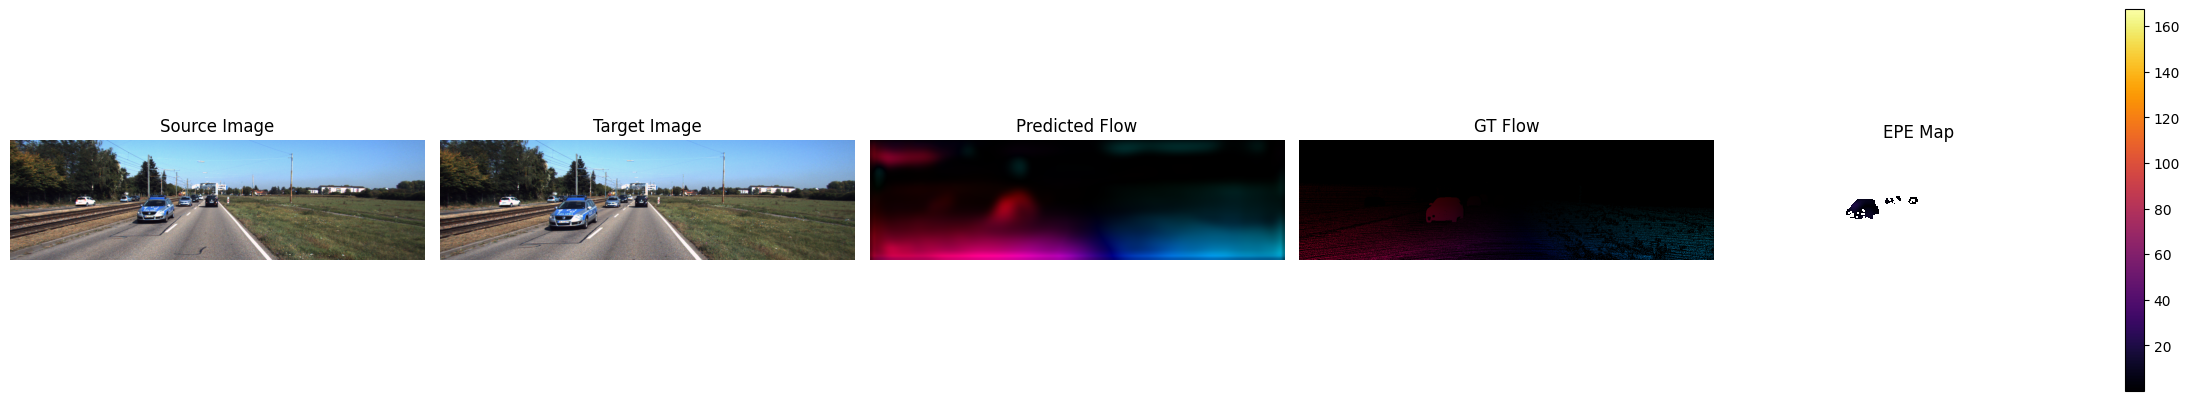

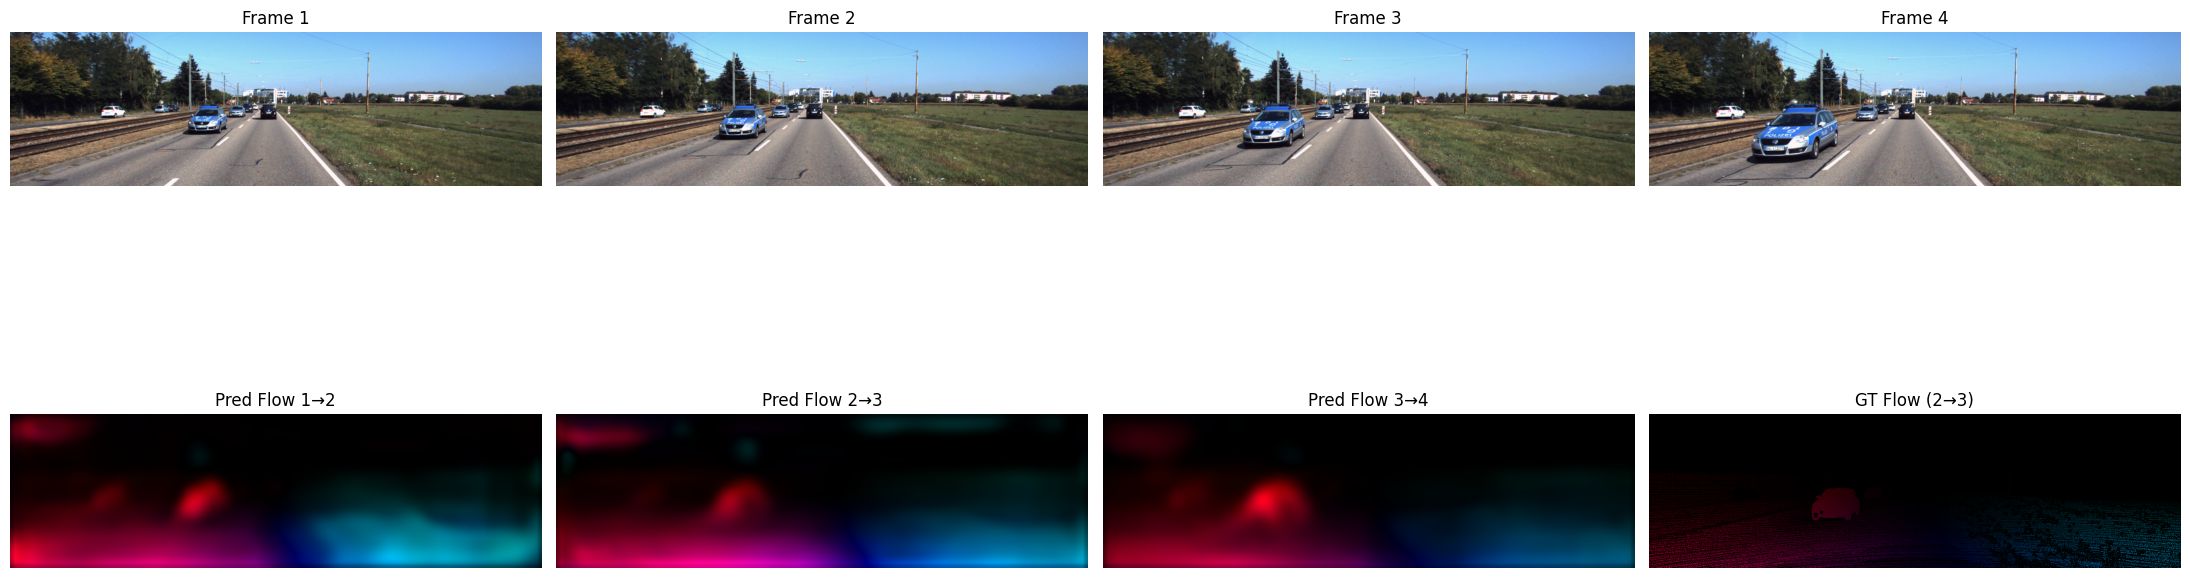

In [13]:
batch = next(iter(train_loader))

imgs = batch["imgs"].to(device)
valid = batch["valid"].to(device)

pair_encoder.eval().to(device)
visual_branch.eval().to(device)
pair_refiner.eval().to(device)
motion_branch.eval().to(device)
fusion.eval().to(device)
decoder.eval().to(device)

with torch.no_grad():
    out = forward_pipeline(
        imgs=imgs,
        pair_encoder=pair_encoder,
        visual_branch=visual_branch,
        pair_refiner=pair_refiner,
        motion_branch=motion_branch,
        fusion=fusion,
        decoder=decoder,
        valid=valid
    )

pred_flows = out["flows"].cpu()
print(pred_flows.shape)

visualize_batch_result(batch, pred_flows, sample_idx=0)
visualize_batch_result_centered(batch, pred_flows, sample_idx=0)

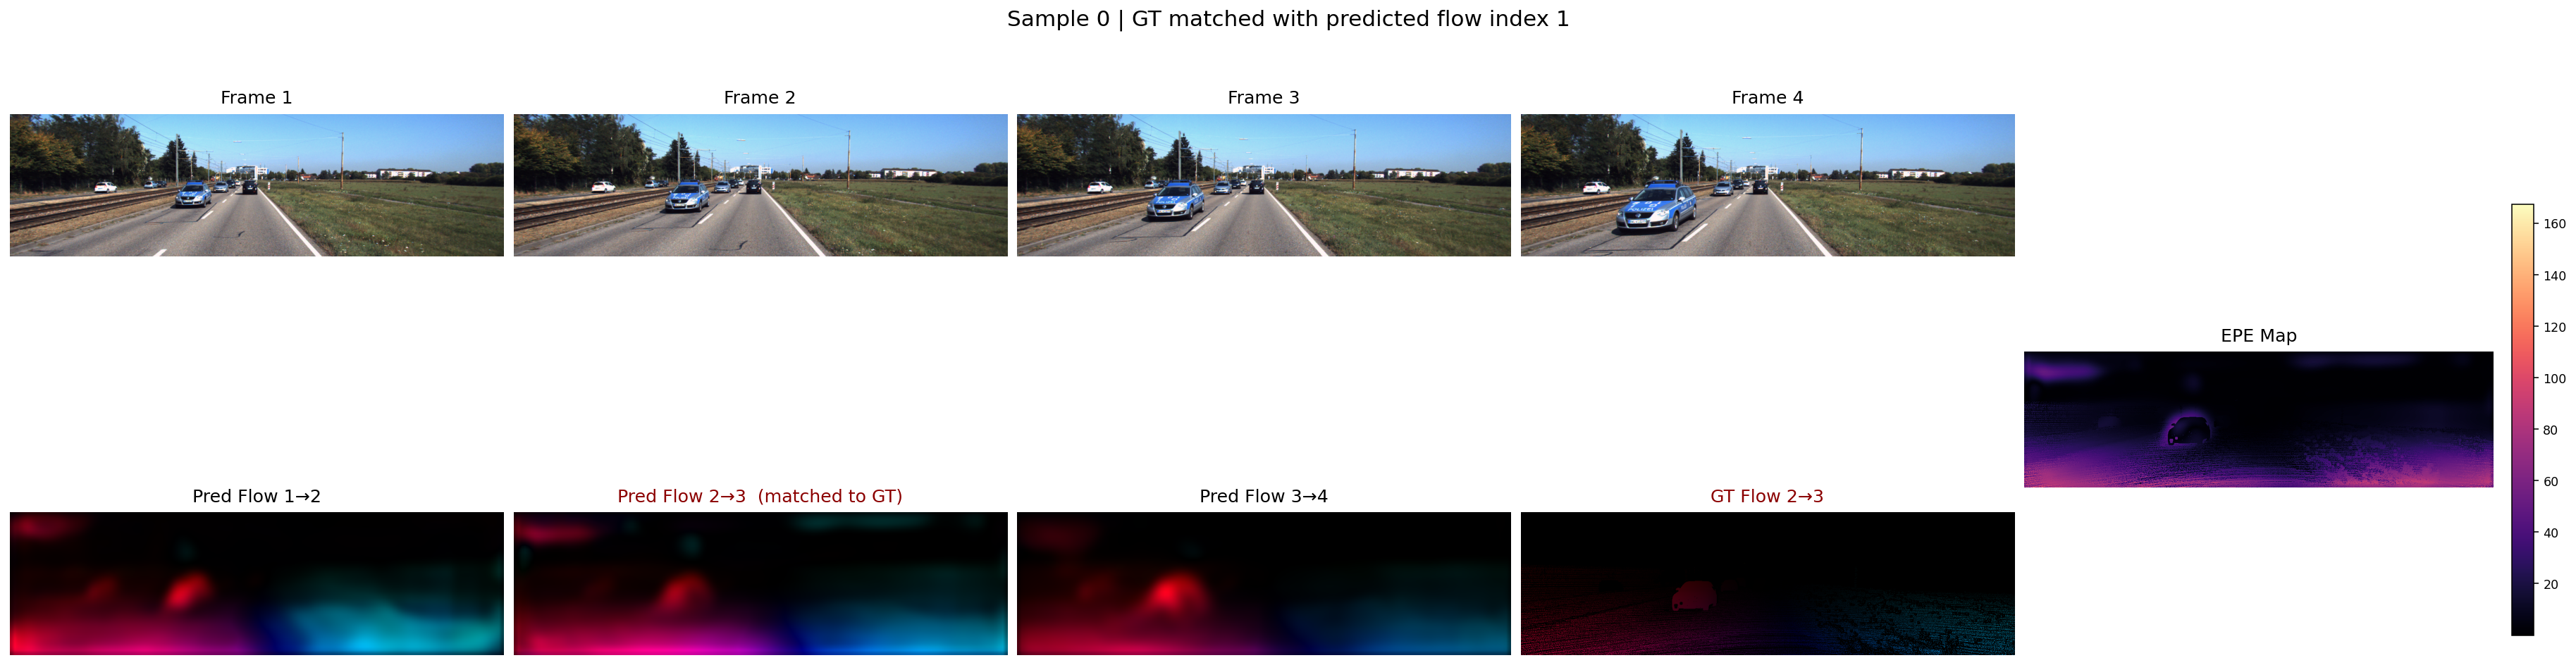

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np


def visualize_batch_result_centered(
    batch,
    pred_flows,
    sample_idx=0,
    save_path=None,
    show_epe=True,
    show_matched_only=False,
    dpi=140,
):
    """
    Better visualization for 4-frame input + 3 predicted flows + GT flow (+ optional EPE).

    Layout:
        Row 1: 4 RGB frames
        Row 2: 3 predicted flows + GT flow (+ optional EPE)

    Improvements:
        - Uses space more efficiently
        - Gives flow maps more vertical room
        - Highlights which predicted flow corresponds to GT
        - Optionally shows EPE map
    """

    imgs = batch["imgs"][sample_idx]          # [4, 3, H, W]
    gt_flow = batch["flow"][sample_idx]       # [2, H, W]
    src_idx = batch["src_idx_in_seq"]
    t = int(src_idx[sample_idx].item())       # GT matches pred_flows[sample_idx, t]

    # ---- Convert images ----
    img_np = [tensor_img_to_np(imgs[i]) for i in range(4)]

    # ---- Convert predicted flows to RGB ----
    pred_rgb = [flow_to_rgb(pred_flows[sample_idx, i]) for i in range(3)]

    # ---- GT and EPE ----
    gt_rgb = flow_to_rgb(gt_flow)
    matched_pred = pred_flows[sample_idx, t]
    epe_map = compute_epe_map(matched_pred, gt_flow, None)

    # ---- Human-readable labeling ----
    human_start = 2 - t
    frame_labels = [f"Frame {human_start + i}" for i in range(4)]
    flow_labels = [
        f"Pred Flow {human_start + 0}→{human_start + 1}",
        f"Pred Flow {human_start + 1}→{human_start + 2}",
        f"Pred Flow {human_start + 2}→{human_start + 3}",
    ]
    gt_label = f"GT Flow {human_start + t}→{human_start + t + 1}"

    # ---- Decide number of columns ----
    if show_matched_only:
        ncols = 3 if show_epe else 2
        width_ratios = [1.15, 1.15] + ([1.0] if show_epe else [])
        fig = plt.figure(figsize=(4.8 * ncols, 7.2), dpi=dpi, constrained_layout=True)
        gs = GridSpec(
            2, ncols,
            figure=fig,
            height_ratios=[1.0, 1.35],
            width_ratios=width_ratios
        )

        # Top row: only the GT pair frames
        ax_f0 = fig.add_subplot(gs[0, 0])
        ax_f1 = fig.add_subplot(gs[0, 1])

        ax_f0.imshow(img_np[t])
        ax_f0.set_title(frame_labels[t], fontsize=13, pad=8)
        ax_f0.axis("off")

        ax_f1.imshow(img_np[t + 1])
        ax_f1.set_title(frame_labels[t + 1], fontsize=13, pad=8)
        ax_f1.axis("off")

        # Bottom row: matched pred + GT (+ EPE)
        ax_p = fig.add_subplot(gs[1, 0])
        ax_g = fig.add_subplot(gs[1, 1])

        ax_p.imshow(pred_rgb[t])
        ax_p.set_title(f"{flow_labels[t]}  (matched)", fontsize=13, pad=8, color="darkred")
        ax_p.axis("off")

        ax_g.imshow(gt_rgb)
        ax_g.set_title(gt_label, fontsize=13, pad=8)
        ax_g.axis("off")

        if show_epe:
            ax_e = fig.add_subplot(gs[1, 2])
            im = ax_e.imshow(epe_map, cmap="magma")
            ax_e.set_title("EPE Map", fontsize=13, pad=8)
            ax_e.axis("off")
            cbar = fig.colorbar(im, ax=ax_e, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=9)

    else:
        ncols = 5 if show_epe else 4
        width_ratios = [1, 1, 1, 1] + ([0.95] if show_epe else [])
        fig = plt.figure(figsize=(5.2 * ncols, 8.0), dpi=dpi, constrained_layout=True)
        gs = GridSpec(
            2, ncols,
            figure=fig,
            height_ratios=[1.0, 1.45],
            width_ratios=width_ratios
        )

        # ---- Top row: 4 frames ----
        top_axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
        for i, ax in enumerate(top_axes):
            ax.imshow(img_np[i])
            ax.set_title(frame_labels[i], fontsize=13, pad=8)
            ax.axis("off")

            # highlight GT source/target frames
            if i == t or i == t + 1:
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(3)
                    spine.set_edgecolor("darkred")

        # ---- Bottom row: 3 preds + GT (+ EPE) ----
        bottom_axes = [fig.add_subplot(gs[1, i]) for i in range(4)]

        for i in range(3):
            ax = bottom_axes[i]
            ax.imshow(pred_rgb[i])

            title = flow_labels[i]
            if i == t:
                title += "  (matched to GT)"
                title_color = "darkred"
            else:
                title_color = "black"

            ax.set_title(title, fontsize=13, pad=8, color=title_color)
            ax.axis("off")

            if i == t:
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(3)
                    spine.set_edgecolor("darkred")

        ax_gt = bottom_axes[3]
        ax_gt.imshow(gt_rgb)
        ax_gt.set_title(gt_label, fontsize=13, pad=8, color="darkred")
        ax_gt.axis("off")
        for spine in ax_gt.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_edgecolor("darkred")

        if show_epe:
            ax_e = fig.add_subplot(gs[:, 4])
            im = ax_e.imshow(epe_map, cmap="magma")
            ax_e.set_title("EPE Map", fontsize=13, pad=8)
            ax_e.axis("off")
            cbar = fig.colorbar(im, ax=ax_e, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=9)

    # ---- Figure-level title ----
    fig.suptitle(
        f"Sample {sample_idx} | GT matched with predicted flow index {t}",
        fontsize=16,
        y=1.02
    )

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=dpi)

    plt.show()
    
visualize_batch_result_centered(
    batch,
    pred_flows,
    sample_idx=0,
    show_epe=True,
    show_matched_only=False, #
)